# <center><strong>Solubility Prediction</strong></center>
--------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

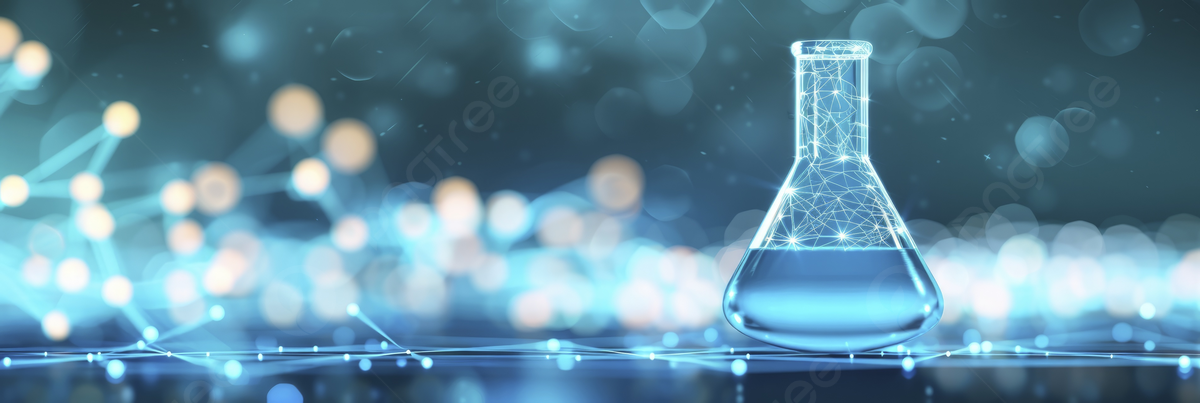

In [1]:
from IPython.display import Image
Image(filename='sol.jpg')

--------------------------------
--------------------------------
## **Project Overview**
#### **This project aims to predict the aqueous solubility of chemical compounds using machine learning and graph-based deep learning approaches. Molecules from the Curated Solubility Dataset are represented as graphs derived directly from SMILES strings, enabling the preservation of atomic and bond-level chemical information.**
--------------------------------
--------------------------------

### **Import Libraries**


In [8]:
!pip install rdkit

In [9]:
!pip install torch_geometric -f https://data.pyg.org/whl/torch-2.5.1+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html


In [10]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.5.1+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html


In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,classification_report,confusion_matrix
from math import sqrt
from pickle import dump
from IPython.display import display, Image
import networkx as nx
import torch
import torch_geometric
import torch.nn.functional as F
from torch.utils.data import random_split, TensorDataset
from torch_geometric.data import InMemoryDataset, download_url, extract_gz,Data

from tqdm import tqdm 
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [12]:
df = pd.read_csv('/kaggle/input/curated-solubility-dataset/curated-solubility-dataset.csv')

In [13]:
df.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17,142,0,0,0,0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0,62,2,0,1,3,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1,46,1,0,0,1,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10,264,6,0,0,6,120.72,323.755434,2.320000e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12,164,2,4,4,6,56.60,183.183268,1.084427e+00,769.899934


In [14]:
df.shape

(9982, 26)

In [15]:
df.columns

Index(['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD',
       'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount',
       'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9982 entries, 0 to 9981
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   9982 non-null   object 
 1   Name                 9982 non-null   object 
 2   InChI                9982 non-null   object 
 3   InChIKey             9982 non-null   object 
 4   SMILES               9982 non-null   object 
 5   Solubility           9982 non-null   float64
 6   SD                   9982 non-null   float64
 7   Ocurrences           9982 non-null   int64  
 8   Group                9982 non-null   object 
 9   MolWt                9982 non-null   float64
 10  MolLogP              9982 non-null   float64
 11  MolMR                9982 non-null   float64
 12  HeavyAtomCount       9982 non-null   int64  
 13  NumHAcceptors        9982 non-null   int64  
 14  NumHDonors           9982 non-null   int64  
 15  NumHeteroatoms       9982 non-null   i

In [17]:
df.isnull().sum()

ID                     0
Name                   0
InChI                  0
InChIKey               0
SMILES                 0
Solubility             0
SD                     0
Ocurrences             0
Group                  0
MolWt                  0
MolLogP                0
MolMR                  0
HeavyAtomCount         0
NumHAcceptors          0
NumHDonors             0
NumHeteroatoms         0
NumRotatableBonds      0
NumValenceElectrons    0
NumAromaticRings       0
NumSaturatedRings      0
NumAliphaticRings      0
RingCount              0
TPSA                   0
LabuteASA              0
BalabanJ               0
BertzCT                0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

---------------------------------
### **Data Cleaning**
---------------------------------

In [19]:
df.columns

Index(['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD',
       'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount',
       'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='object')

In [20]:
df.rename(columns={'InChI': 'International Chemical Identifier', 
                   'InChIKey':'International Chemical Identifier Key', 
                   'SMILES': 'Simplified Molecular Input Line Entry System', 
                   'SD':'Experimental uncertainty (SD)',
                   'Ocurrences':'Number of Occurrences', 
                   'Group':'Chemical Group',
                   'MolWt':'Molecular Weight',
                   'MolLogP':'Molecular Log Partition Coefficient',
                   'MolMR':'Molecular Molar Refractivity',
                   'NumHAcceptors':'Number of Hydrogen Bond Acceptors',
                   'NumHDonors':'Number of Hydrogen Bond Donors',
                   'NumHeteroatoms':'Number of Heteroatoms',
                   'NumRotatableBonds':'Number of Rotatable Bonds',
                   'NumValenceElectrons':'Number of Valence Electrons',
                   'NumAromaticRings':'Number of Aromatic Rings',
                   'NumSaturatedRings':'Number of Saturated Rings',
                   'NumAliphaticRings':'Number of Aliphatic Rings',
                   'RingCount':'Total Ring Count',
                   'TPSA':'Topological Polar Surface Area',
                   'LabuteASA':'Labute Approximate Surface Area',
                   'BalabanJ':'Balaban Connectivity Index',
                   'BertzCT':'Bertz Complexity Index'} ,inplace=True)

In [21]:
df['Solubility without log'] = df['Solubility'].apply(lambda x :np.exp(x))

In [22]:
df.columns

Index(['ID', 'Name', 'International Chemical Identifier',
       'International Chemical Identifier Key',
       'Simplified Molecular Input Line Entry System', 'Solubility',
       'Experimental uncertainty (SD)', 'Number of Occurrences',
       'Chemical Group', 'Molecular Weight',
       'Molecular Log Partition Coefficient', 'Molecular Molar Refractivity',
       'HeavyAtomCount', 'Number of Hydrogen Bond Acceptors',
       'Number of Hydrogen Bond Donors', 'Number of Heteroatoms',
       'Number of Rotatable Bonds', 'Number of Valence Electrons',
       'Number of Aromatic Rings', 'Number of Saturated Rings',
       'Number of Aliphatic Rings', 'Total Ring Count',
       'Topological Polar Surface Area', 'Labute Approximate Surface Area',
       'Balaban Connectivity Index', 'Bertz Complexity Index',
       'Solubility without log'],
      dtype='object')

-----------------------------------------

#### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Solubility,9982.0,-2.889909,2.368154,-13.171900,-4.326325,-2.618173,-1.209735,2.137682
Experimental uncertainty (SD),9982.0,0.067449,0.234702,0.000000,0.000000,0.000000,0.000000,3.870145
Number of Occurrences,9982.0,1.378081,1.023476,1.000000,1.000000,1.000000,1.000000,38.000000
Molecular Weight,9982.0,266.665946,184.179024,9.012000,162.276000,228.682000,320.436000,5299.456000
Molecular Log Partition Coefficient,9982.0,1.979167,3.517738,-40.873200,0.619750,1.949220,3.419030,68.541140
Molecular Molar Refractivity,9982.0,66.794594,46.523021,0.000000,40.602475,58.633400,81.938000,1419.351700
HeavyAtomCount,9982.0,17.374674,12.241536,1.000000,11.000000,15.000000,21.000000,388.000000
Number of Hydrogen Bond Acceptors,9982.0,3.486776,3.498203,0.000000,2.000000,3.000000,4.000000,86.000000
Number of Hydrogen Bond Donors,9982.0,1.108595,1.488973,0.000000,0.000000,1.000000,2.000000,26.000000
Number of Heteroatoms,9982.0,5.196955,4.736275,0.000000,3.000000,4.000000,6.000000,89.000000


In [24]:
df.select_dtypes(include='object').describe()

,ID,Name,International Chemical Identifier,International Chemical Identifier Key,Simplified Molecular Input Line Entry System,Chemical Group
count,9982,9982,9982,9982,9982,9982
unique,9982,9893,9982,9982,9982,5
top,I-94,tetracycline,InChI=1S/C19H16O4/c1-12(20)11-15(13-7-3-2-4-8-...,PJVWKTKQMONHTI-UHFFFAOYSA-N,CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O,G1
freq,1,3,1,1,1,7746


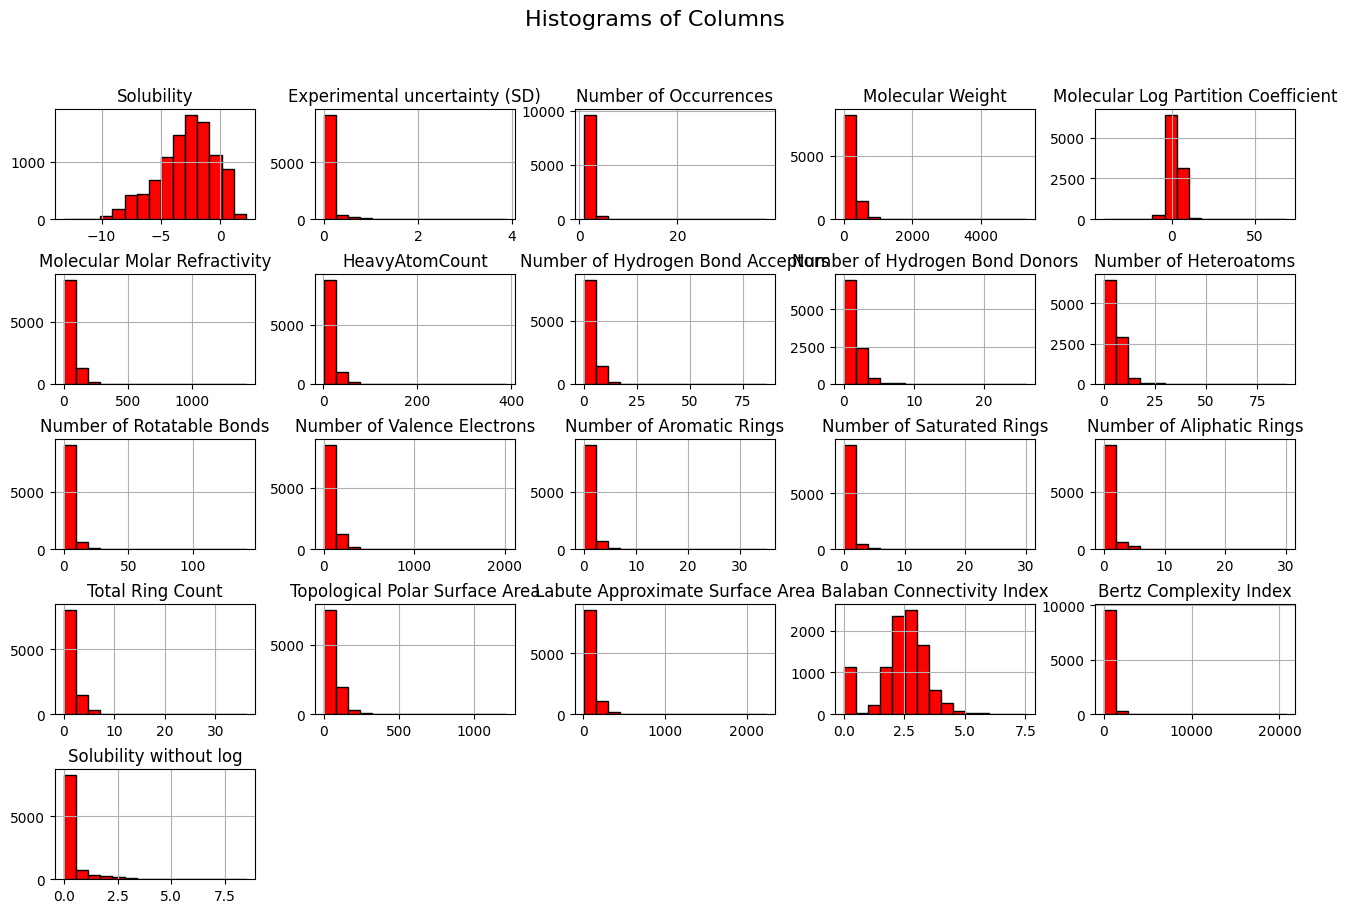

In [25]:
df.hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')

 # Set titles and labels for each subplot
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  # Add space between plots
plt.show()

--------------------------------
- Summary Statistical : **value_counts()**
--------------------------------

In [26]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def countplot(data,col):
    plt.fig,ax= plt.subplots()
    plt.fig.set_size_inches(18,5)    
    sns.countplot(x=data[col], data=df)
    plt.xlabel(col)
    plt.xticks(rotation = 45)
    plt.show()

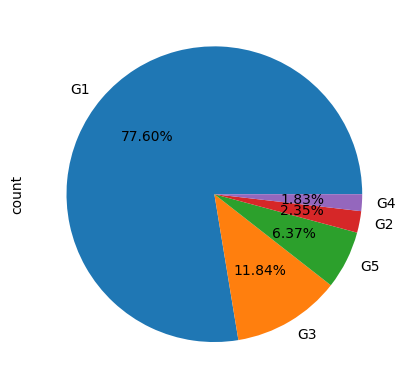

In [27]:
pie(df,'Chemical Group')

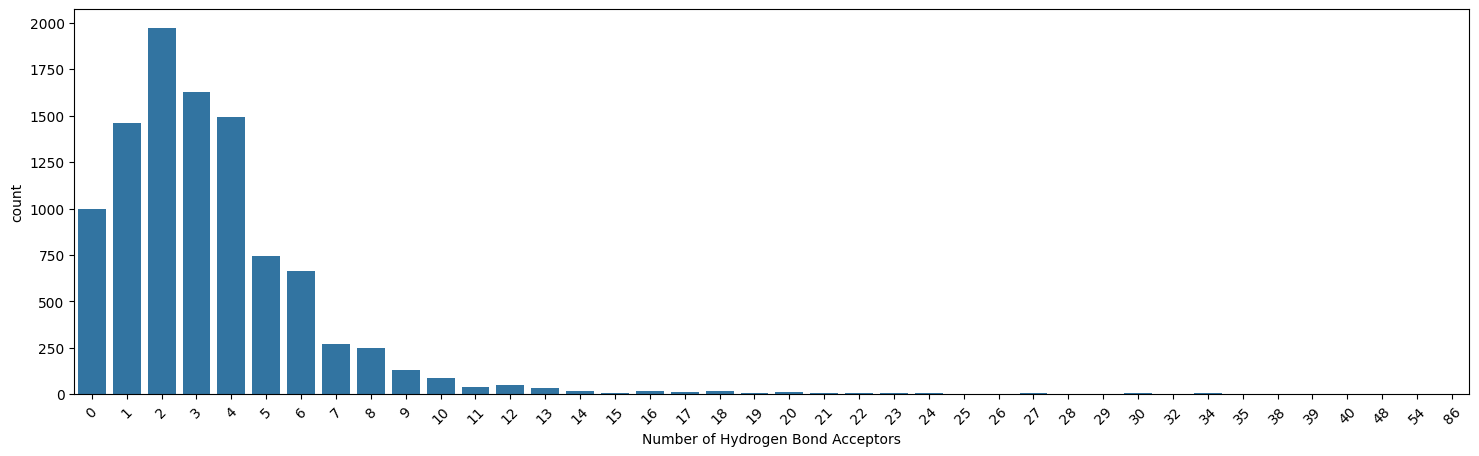

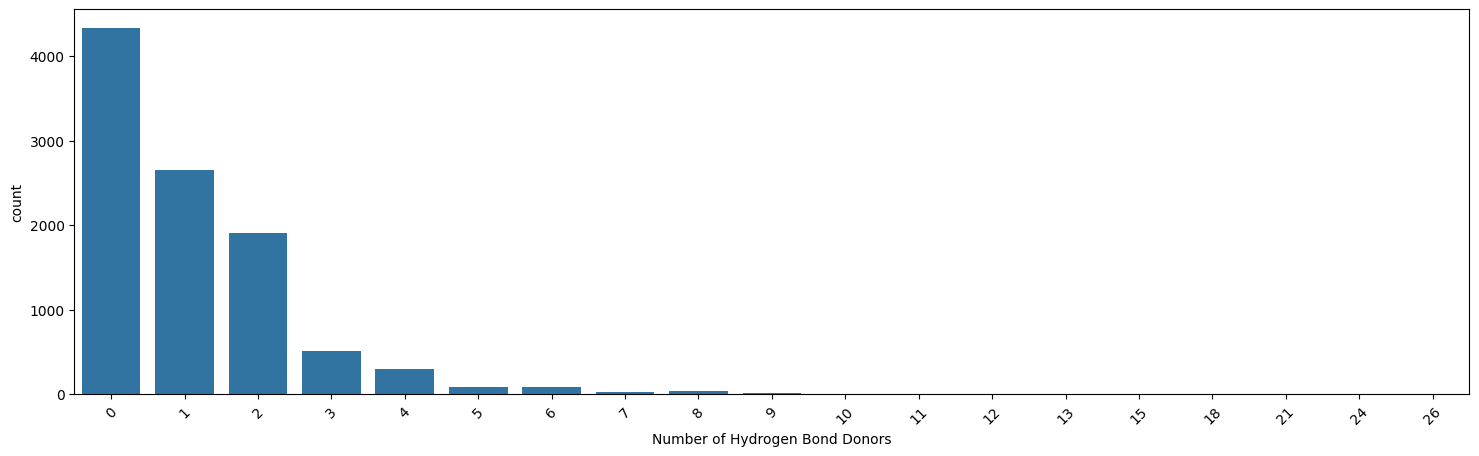

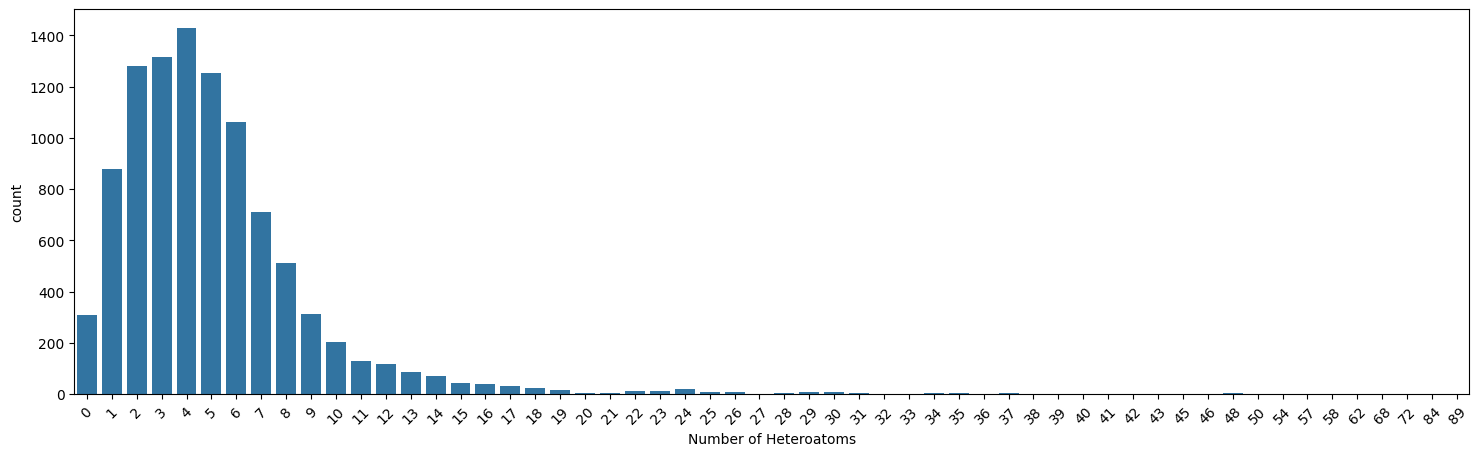

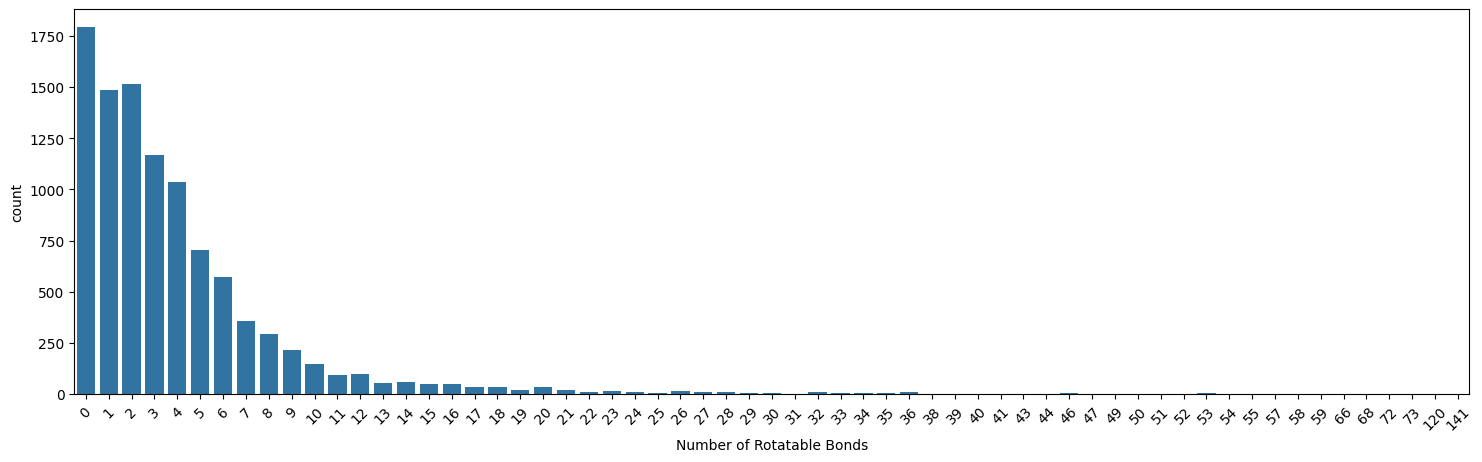

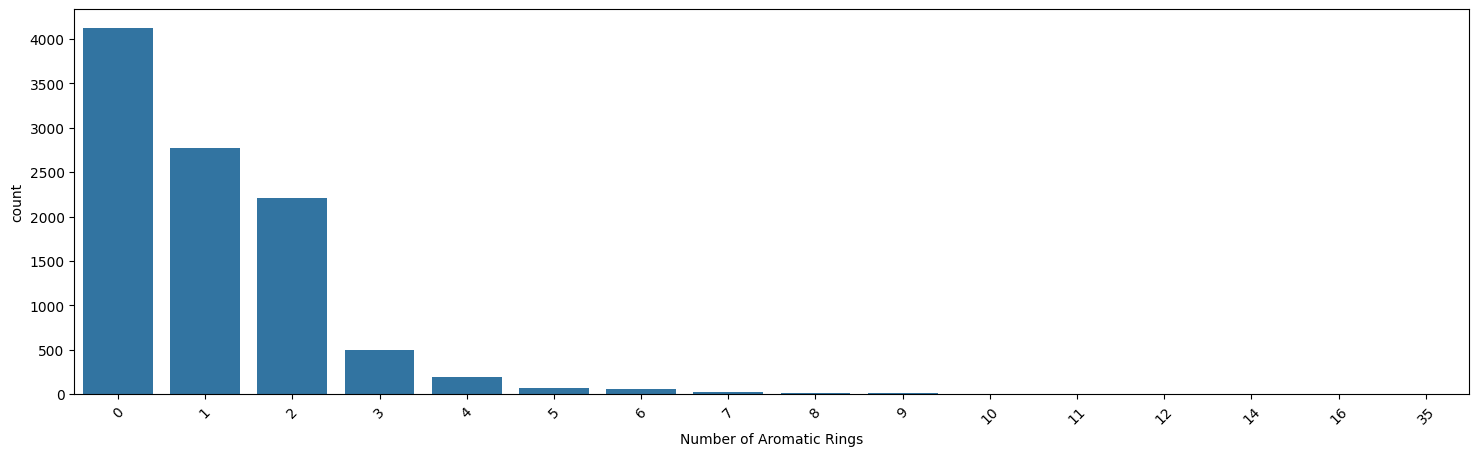

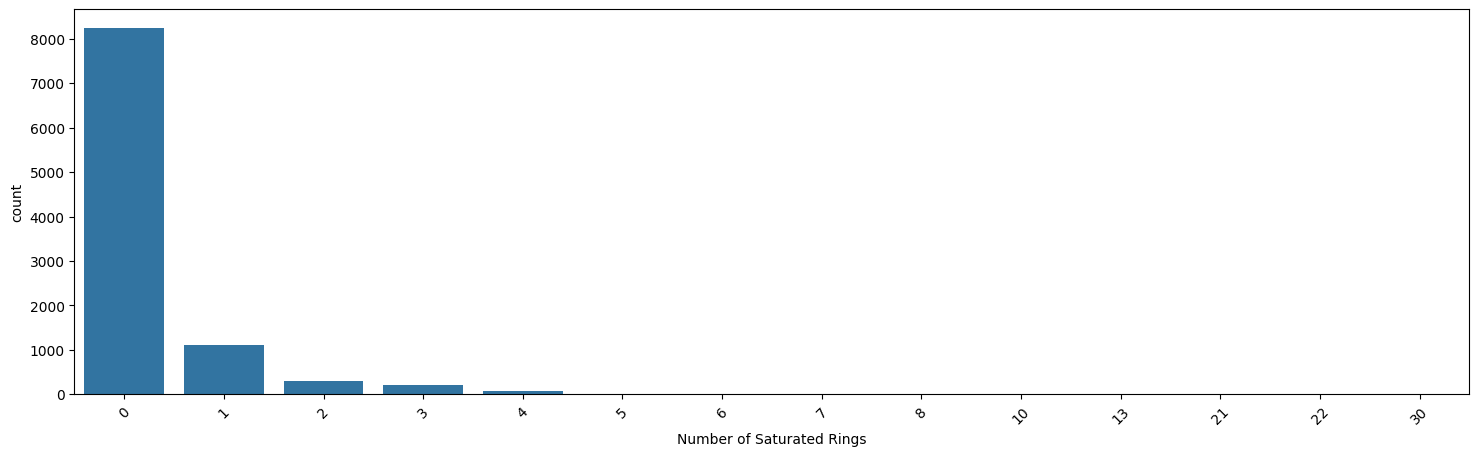

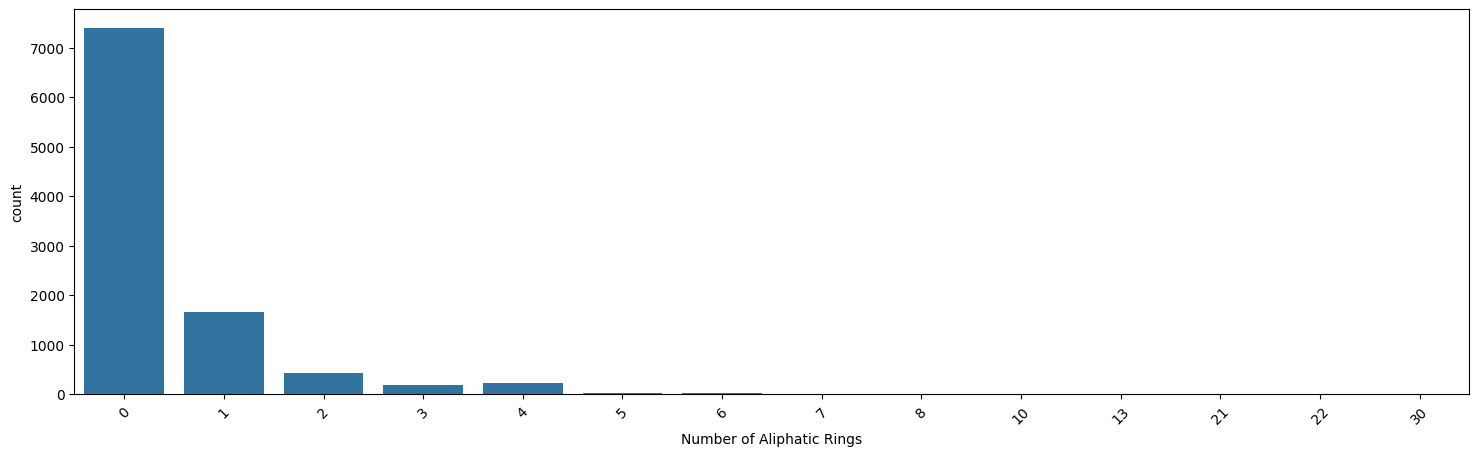

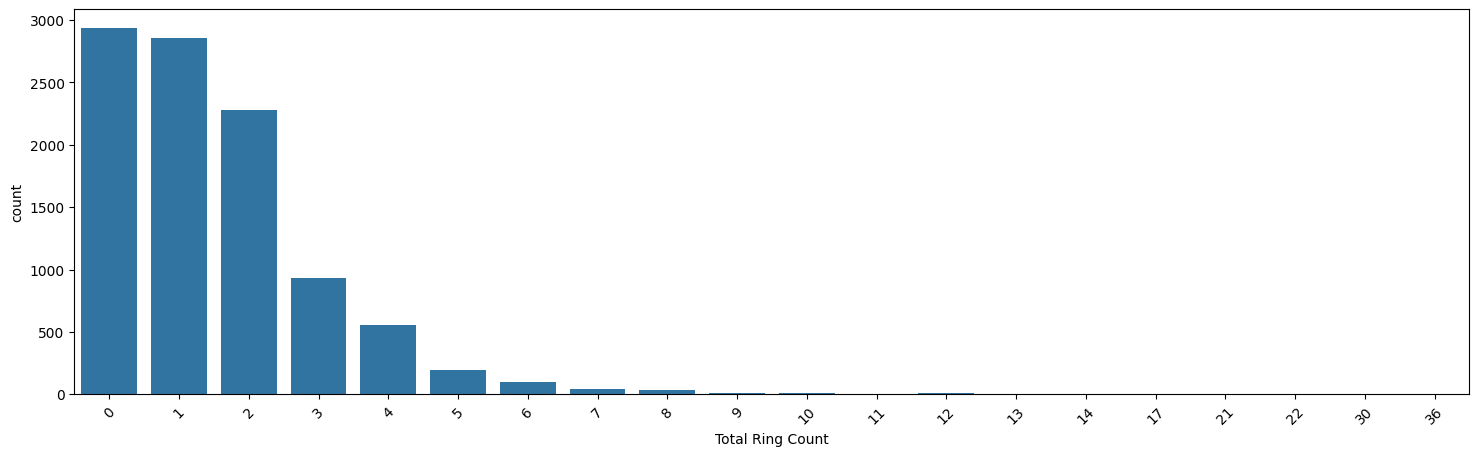

In [28]:
columns = ['Number of Hydrogen Bond Acceptors',
       'Number of Hydrogen Bond Donors', 'Number of Heteroatoms',
       'Number of Rotatable Bonds','Number of Aromatic Rings', 
       'Number of Saturated Rings',
       'Number of Aliphatic Rings', 'Total Ring Count']
for col in columns:
    countplot(df,col)

-----------------------------------
#### **Numerical Features (KDE)**
-----------------------------------

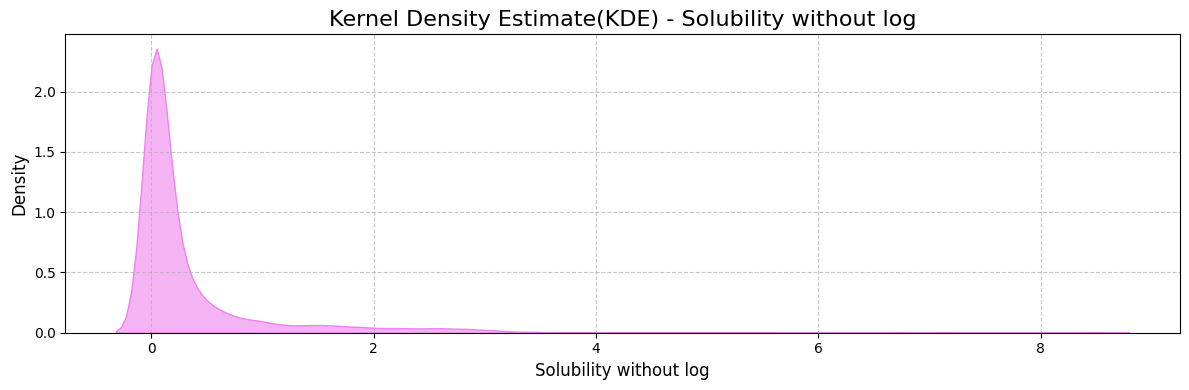

In [29]:
plt.figure(figsize=(12,	4))
sns.kdeplot(df['Solubility without log'], fill=True,	color='violet', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - Solubility without log',	fontsize=16)
plt.xlabel('Solubility without log', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

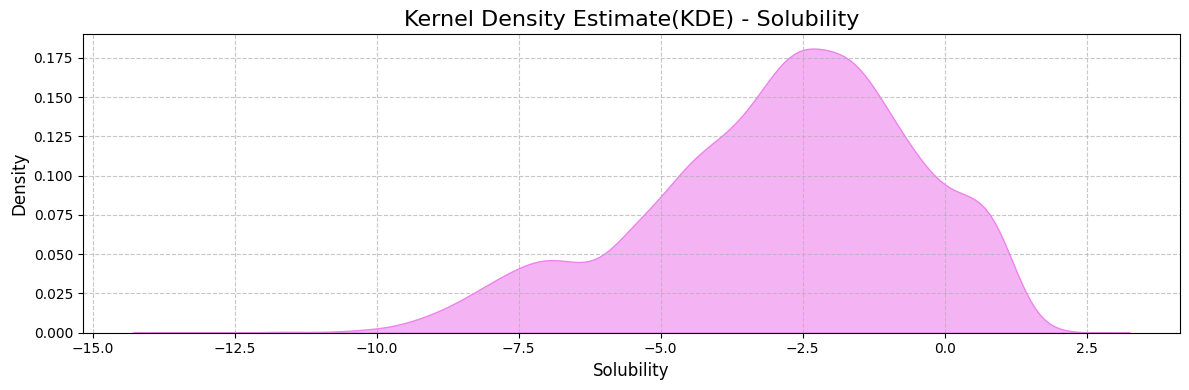

In [30]:
plt.figure(figsize=(12,	4))
sns.kdeplot(df['Solubility'], fill=True,	color='violet', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - Solubility',	fontsize=16)
plt.xlabel('Solubility', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---------------------------------------
#### **Checking Correlation between the features**
---------------------------------------

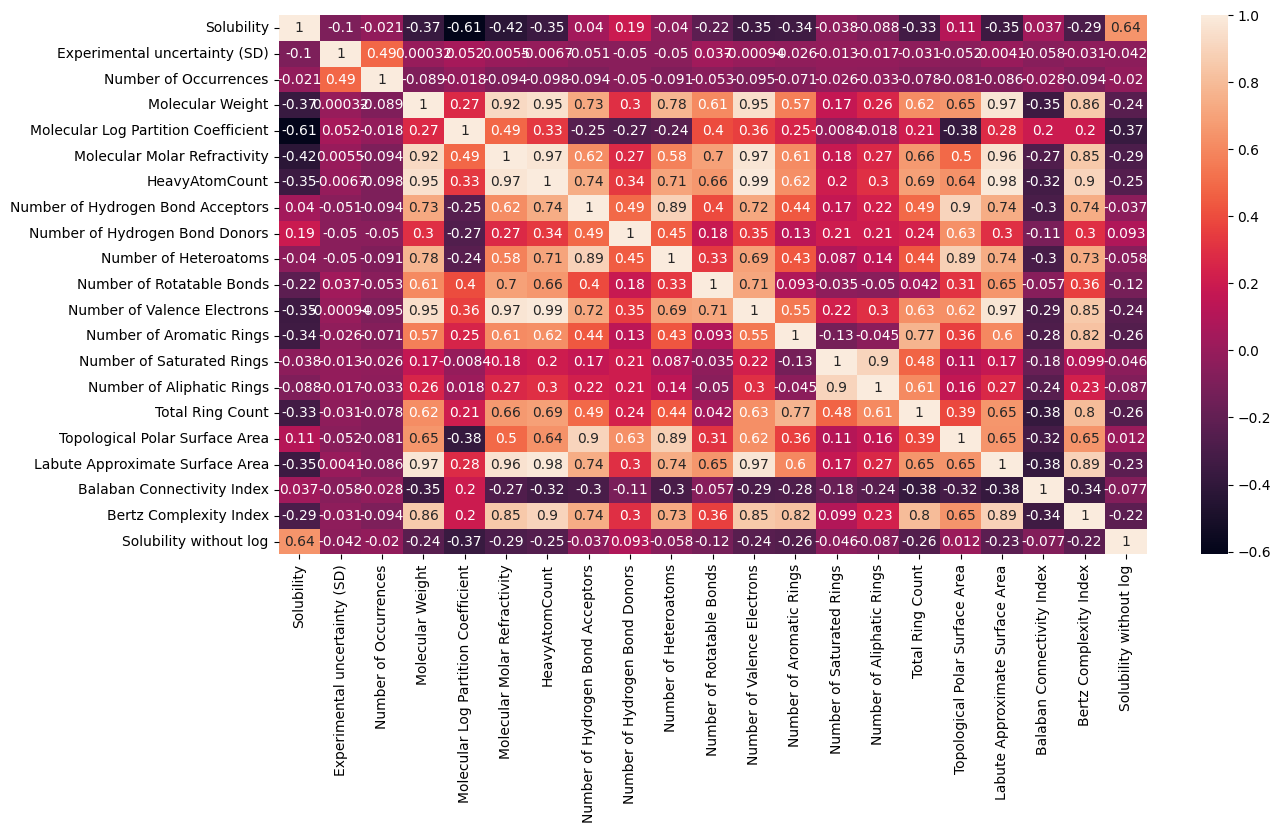

In [31]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

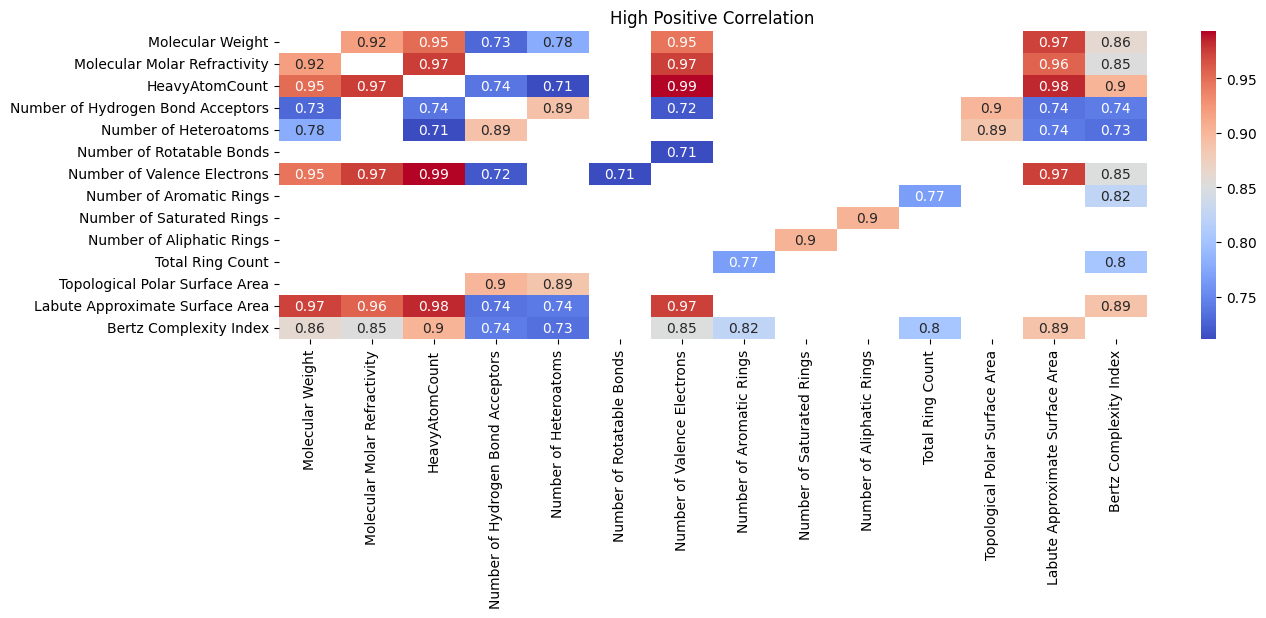

In [32]:
# function to extract high positive correlated columns
def get_high_corr(df, threshold):
    corr = df.select_dtypes('number').corr()
    high_corr = corr[(corr >= threshold) & (corr != 1.000)]
    high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
    return high_corr

# get high positive correlated columns
high_corr = get_high_corr(df, 0.7)

# plot high positive correlated columns
plt.figure(figsize=(14, 4))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Positive Correlation')
plt.show()

In [33]:
# plot scatter plot for high correlated columns
def scatter(df, x, y):
    plt.figure(figsize=(14, 4))
    ax = sns.scatterplot(x=x, y=y, data=df)
    #ax.set_title(title)
    plt.show()

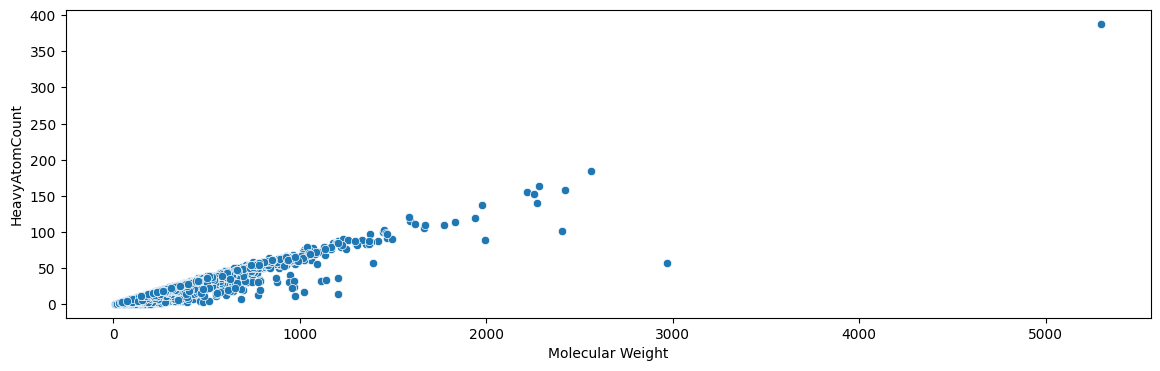

In [34]:
scatter(df,'Molecular Weight','HeavyAtomCount')

- #### **Increasing the number of heavier atoms (C, N, O…) ⇒ Weight increases linearly**
----------------------------------

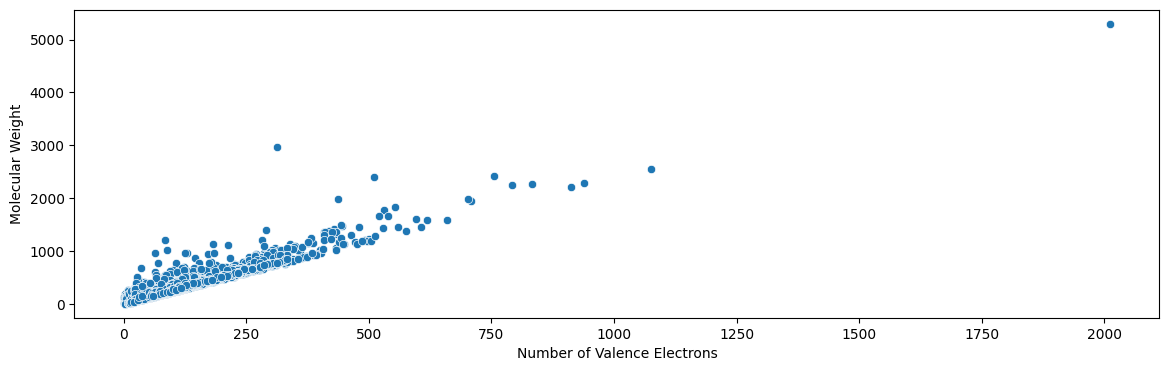

In [35]:
scatter(df,'Number of Valence Electrons','Molecular Weight')

- #### **Each atom adds valence electrons.**
- #### **Larger molecules contain more electrons.**
----------------------------------

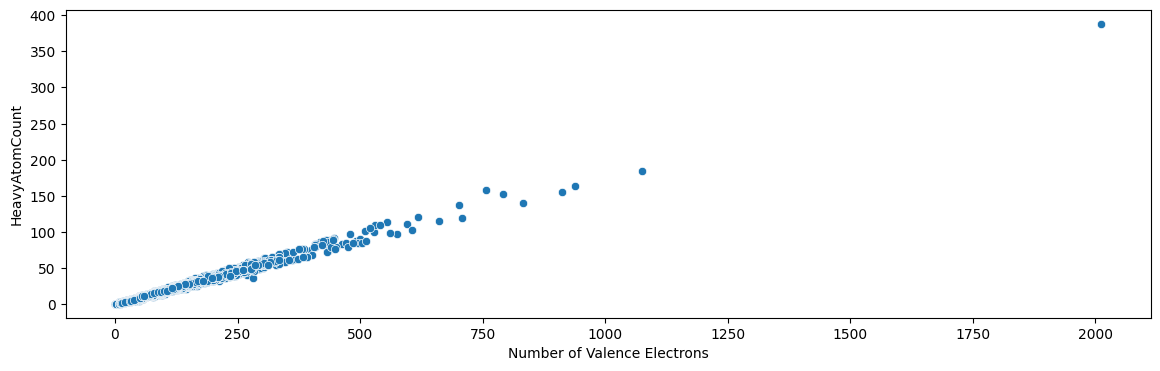

In [36]:
scatter(df,'Number of Valence Electrons','HeavyAtomCount')

- #### **Every heavy atom has a fixed number of valence electrons**
----------------------------------

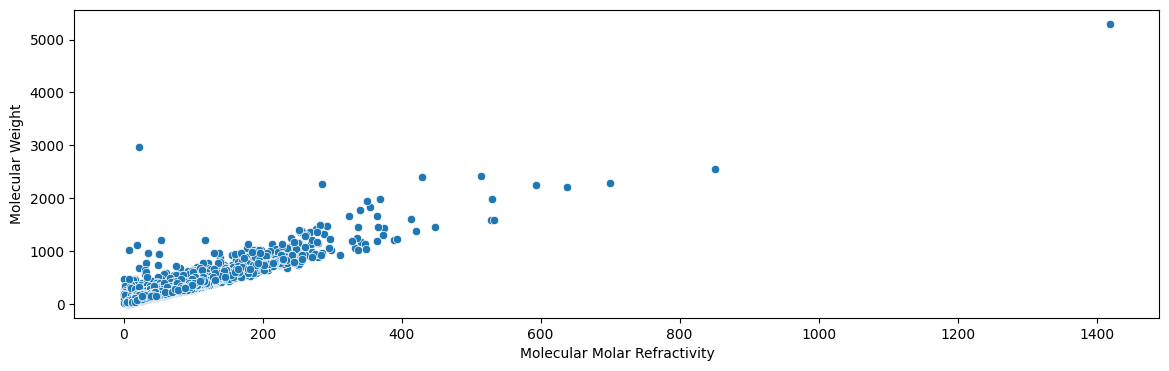

In [37]:
scatter(df,'Molecular Molar Refractivity','Molecular Weight')

- #### **Larger particles ⇒ Larger electron cloud**
----------------------------------

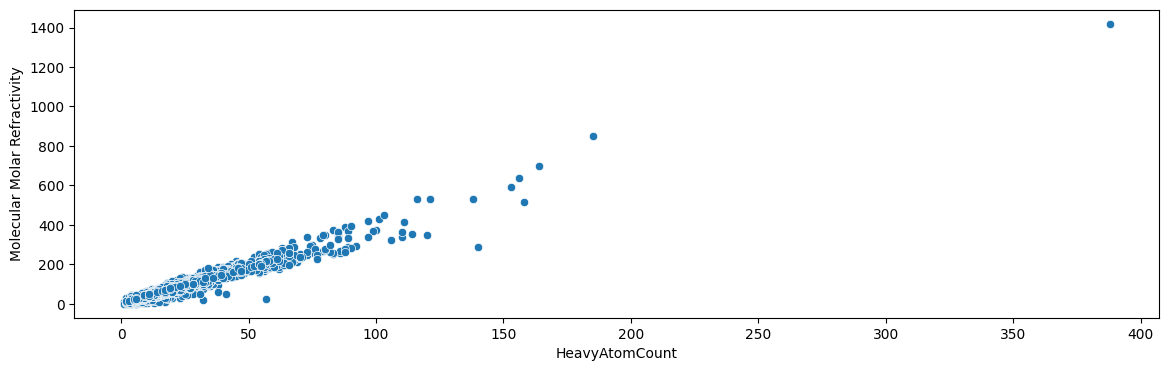

In [38]:
scatter(df,'HeavyAtomCount','Molecular Molar Refractivity')

- #### **Each atom adds an electron cloud ,Especially the heavy atoms (O, N, S)**
----------------------------------

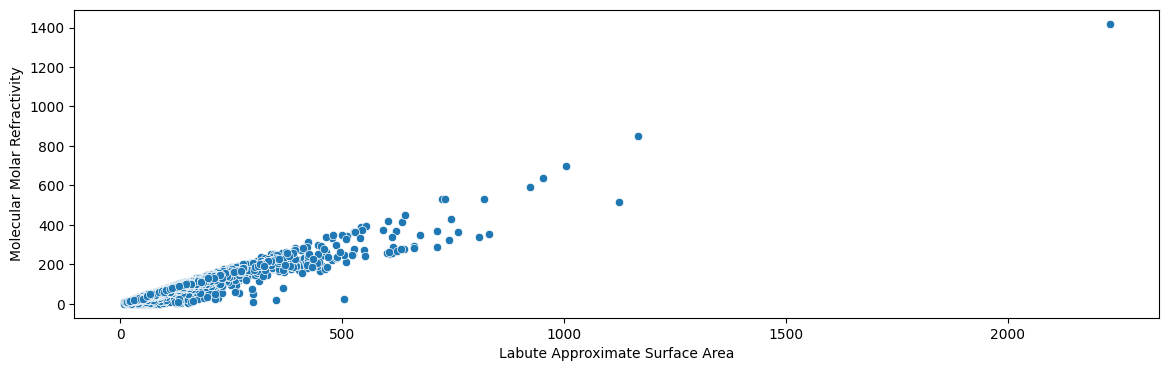

In [39]:
scatter(df,'Labute Approximate Surface Area','Molecular Molar Refractivity')

- #### **Electronic volume ⇒ surface area**
----------------------------------

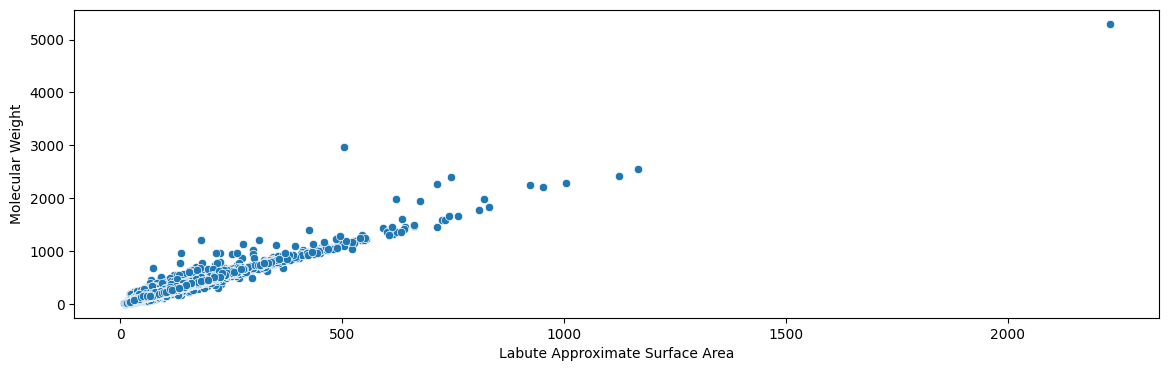

In [40]:
scatter(df,'Labute Approximate Surface Area','Molecular Weight')

- #### **The larger the molecule ⇒ the greater its surface area**
----------------------------------

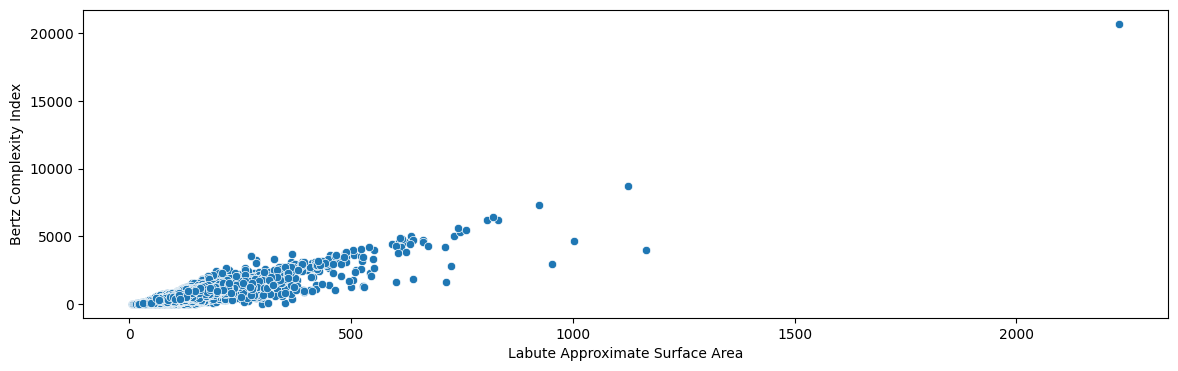

In [41]:
scatter(df,'Labute Approximate Surface Area','Bertz Complexity Index')

#### **Complex molecules are typically:**
- #### **Larger**
- #### **Have a more complex surface**
----------------------------------

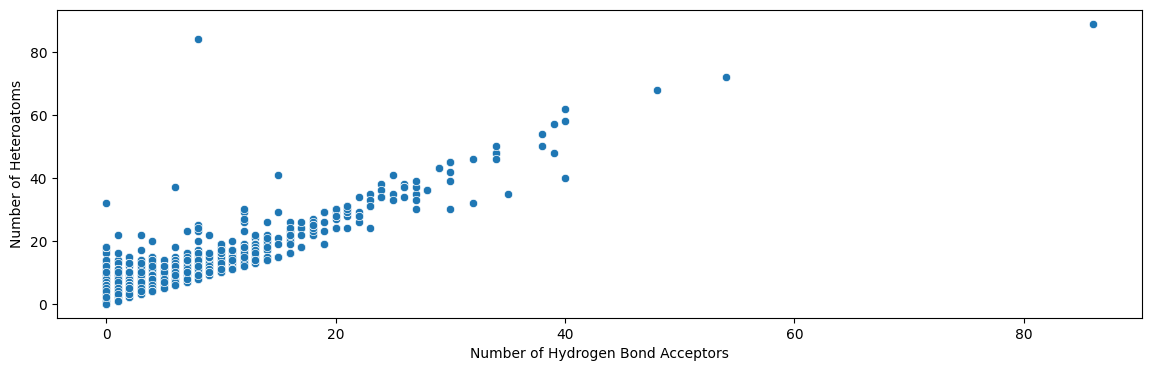

In [42]:
scatter(df,'Number of Hydrogen Bond Acceptors','Number of Heteroatoms')

- #### **Heteroatoms (O, N, S) ⇒ Often H-bond receptors**
----------------------------------

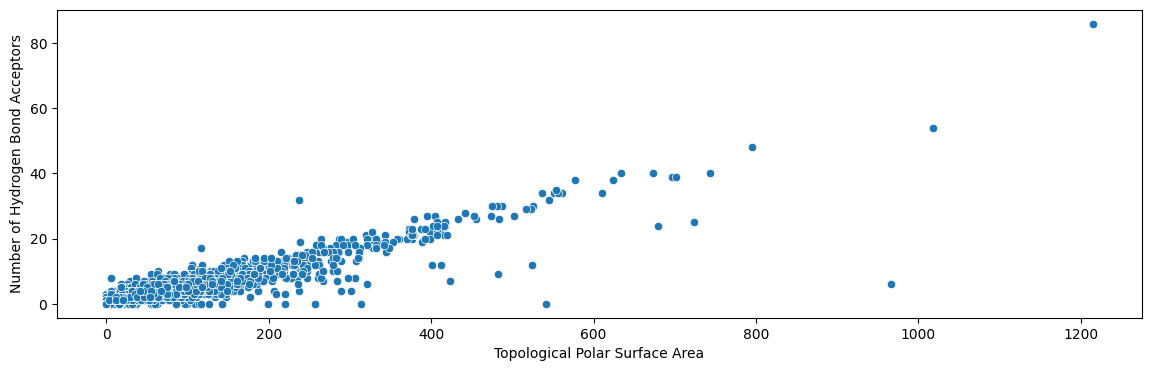

In [43]:
scatter(df,'Topological Polar Surface Area','Number of Hydrogen Bond Acceptors')

- #### **TPSA is calculated from O & N**
- #### **Each H-bond receiver adds polarity space**
--------------------------

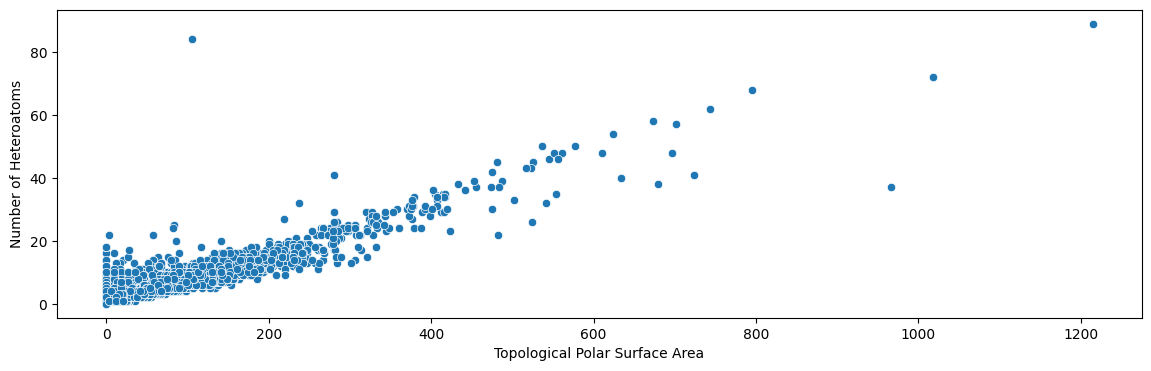

In [44]:
scatter(df,'Topological Polar Surface Area','Number of Heteroatoms')

- #### **Heteroatoms increase polarity**
- #### **Increase reactivity with water**
----------------------------------

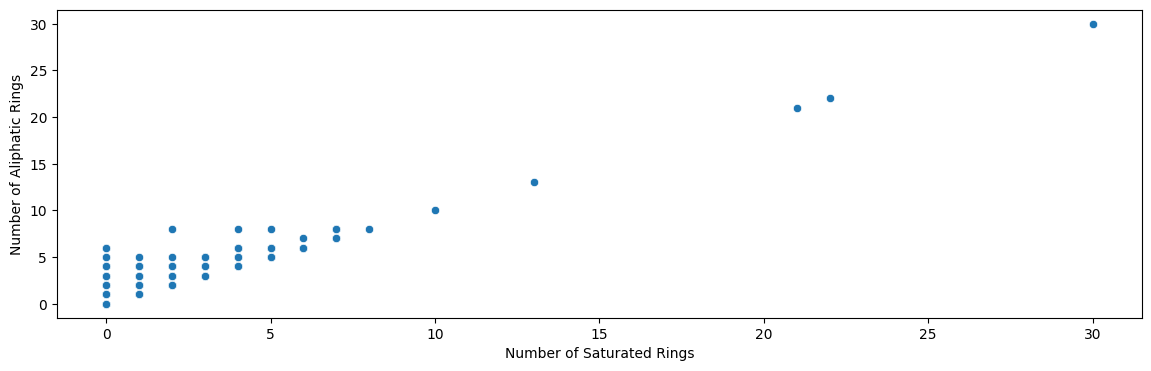

In [45]:
scatter(df,'Number of Saturated Rings','Number of Aliphatic Rings')

- #### **Aliphatic rings are often saturated**
-----------------------

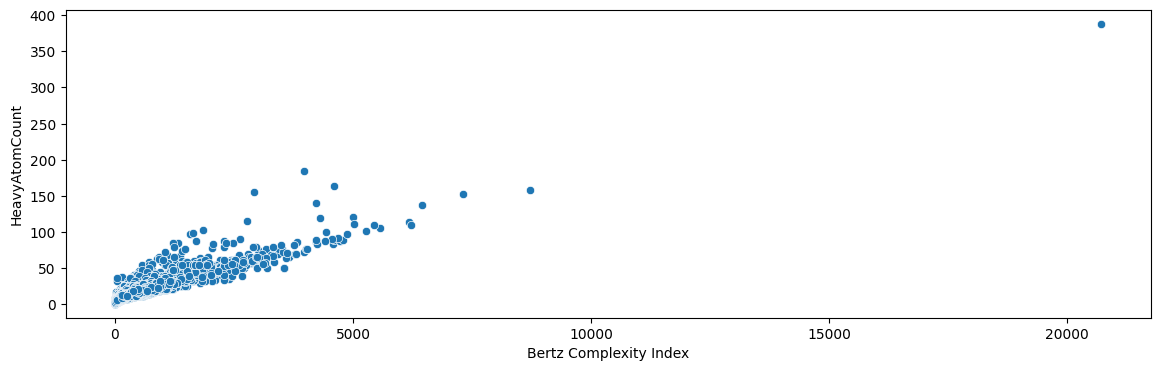

In [46]:
scatter(df,'Bertz Complexity Index','HeavyAtomCount')

- #### **As the number of atoms increases, complexity increases.**
---------------------------

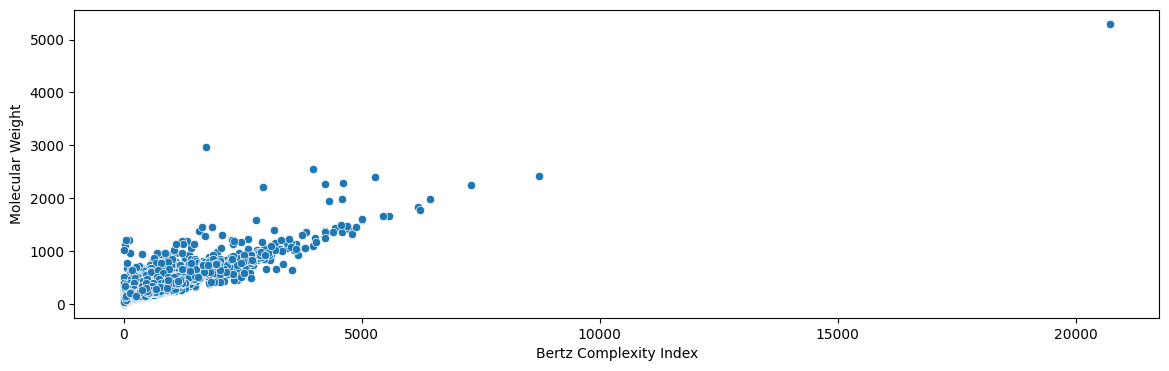

In [47]:
scatter(df,'Bertz Complexity Index','Molecular Weight')

- #### **Heavy molecules are often: More complex & Polycyclic**
--------------------------

#### **The relationship of these results to solubility** : 
- #### **Size ↑ → Solubility ↓**
- #### **Polarity ↑ → Solubility ↑**
- #### **Complexity ↑ → Solubility ↓**
----------------------------

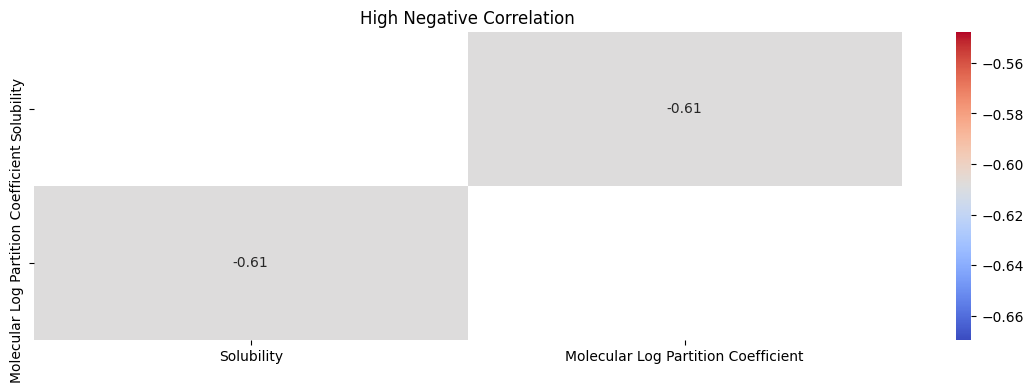

In [48]:
# function to extract high negative correlated columns
def get_high_corr(df, threshold):
    corr = df.select_dtypes('number').corr()
    high_corr = corr[(corr <= threshold) & (corr != 1.000)]
    high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
    return high_corr

# get high negative correlated columns
high_corr = get_high_corr(df, -0.5)

# plot high negative correlated columns
plt.figure(figsize=(14, 4))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Negative Correlation')
plt.show()

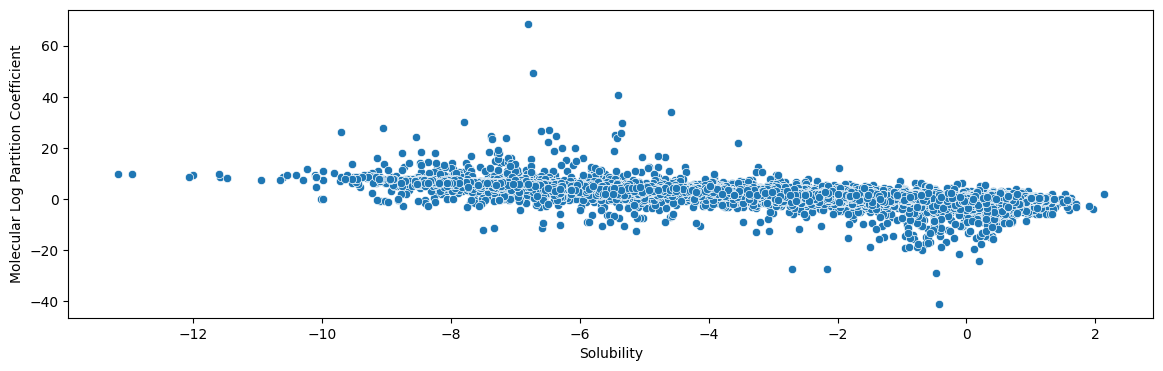

In [49]:
scatter(df,'Solubility','Molecular Log Partition Coefficient')

##### **Water is polar**
##### **Compounds with a high LogP:**
-    ##### **Nonpolar**
-    ##### **Prefer a lipid medium (octanol)**
##### **Do not form strong hydrogen bonds with water ⇒ Poor solubility**
--------------------------------------------
##### **Low LogP + Poor solubility**
##### **Molecular structure: Very large or Solid (strong crystal lattice)**
##### **Solubility is also affected by crystal structure**

---------------------------------
---------------------------------

#### **Detect Outliers**

-------------------------

In [50]:
df['Solubility'].describe()

count    9982.000000
mean       -2.889909
std         2.368154
min       -13.171900
25%        -4.326325
50%        -2.618173
75%        -1.209735
max         2.137682
Name: Solubility, dtype: float64

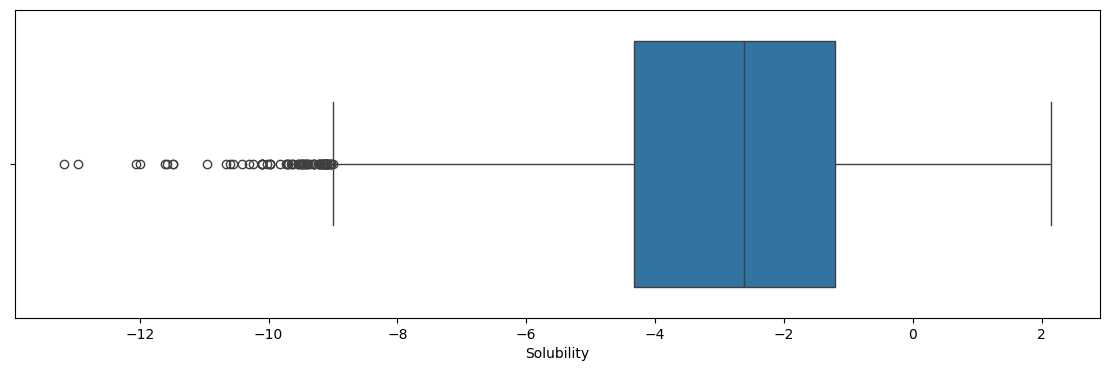

In [51]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(14, 4)
sns.boxplot(data=df,x="Solubility",orient="o",ax=axes)
plt.show()

##### **Moving to the right → increases solubility**
##### **Left → Very low solubility**
-------------------------------
##### **Median ≈ -2.5 → Most compounds are not highly soluble**
##### **Right Whisker: Up to ≈ +2 → Highly soluble compounds (very polar)**
##### **Left Whisker: Up to ≈ -9 → Very poorly soluble compounds**
-----------------------------
##### **Long tail weak solubility side :**
##### **Chemical cause:**
- ##### **Many of the compounds are: Large-sized and Polycyclic and Prefer a lipid (high LogP)**
- ##### **These properties: They reduce reaction with water and They increase the energy of the crystal lattice**
#### **----> Very low solubility**

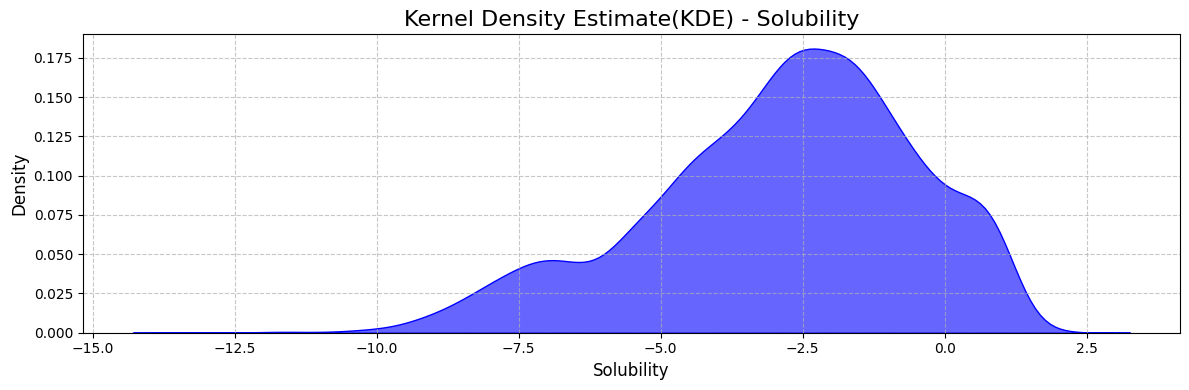

In [52]:
plt.figure(figsize=(12,	4))
sns.kdeplot(df['Solubility'], fill=True,	color='blue', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - Solubility',	fontsize=16)
plt.xlabel('Solubility', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **The solubility distribution exhibits a strong left-skewness, with a long tail towards poorly soluble compounds. This behavior reflects the dominance of large, hydrophobic, and structurally complex molecules within the dataset, which is characteristic of drug-like chemical space.**

--------------------------------
--------------------------------
#### **Feature selection**
--------------------------------

In [53]:
data_selected = df[['Molecular Weight',
    'Molecular Log Partition Coefficient',
    'Topological Polar Surface Area',
    'Number of Rotatable Bonds',
    'Total Ring Count',
    'Balaban Connectivity Index',
    'Bertz Complexity Index',
    'Solubility']]

-------------------------------------------
-------------------------------------------
## **Predictive Model**
------------------------------------------

In [54]:
x=data_selected.drop('Solubility',axis=1)
y=data_selected['Solubility']

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.9,random_state=1234)

In [55]:
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')

shape of x_train : (8983, 7)
shape of x_test : (999, 7)
-------------------------------
shape of y_train : (8983,)
shape of y_test : (999,)


In [56]:
r_2=[]
rmse=[]
mae=[]

def Regression_func(model):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    R2 = r2_score(y_test, pred)
    RMSE = sqrt(mean_squared_error(y_test, pred))
    MAE = mean_absolute_error(y_test, pred)

    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

### **Hyperparameter Tuning**

In [57]:
XGBRegressor_model	= XGBRegressor(n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42)

RandomForestRegressor_model = RandomForestRegressor()

In [58]:
Regression_func(XGBRegressor_model)

In [59]:
Regression_func(RandomForestRegressor_model)

In [60]:
Algorithms = ['XGBRegressor','RandomForestRegressor_model']

In [61]:
result=pd.DataFrame({'Algorithms':Algorithms,'R2':r_2,'rmse':rmse,'mae':mae})
result

,Algorithms,R2,rmse,mae
0,XGBRegressor,0.747792,1.166411,0.818039
1,RandomForestRegressor_model,0.751257,1.158371,0.780310


#### **RF vs XGBoost Comparison**
#### **1- Random Forest**
- #####    **Slightly higher R²**
- #####    **Lower RMSE and MAE**
- #####    **More stable**
- #####    **Less sensitive to hyperparameters**

#### **2- XGBoost**
- #####    **Strong with tuning**
- #####    **Learns more precise interactions**
- #####    **Requires finer tuning to achieve optimal performance**

##### **The difference is very small → The two models are almost equivalent**

----------------------------------
### **Residual Analysis**
----------------------------------

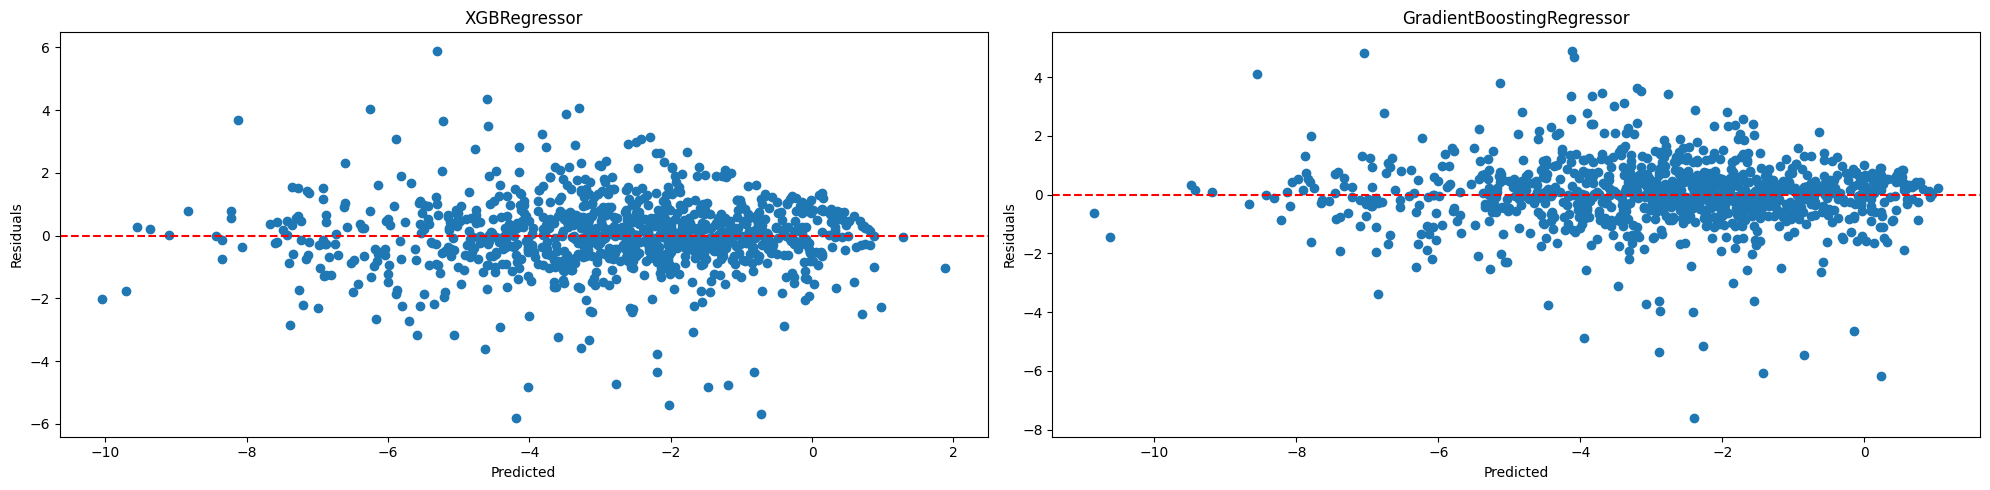

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))  

residuals_xgb = y_test - XGBRegressor_model.predict(x_test)
axes[0].scatter(XGBRegressor_model.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y_test - RandomForestRegressor_model.predict(x_test)
axes[1].scatter(RandomForestRegressor_model.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("GradientBoostingRegressor")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

------------------------------
### **Chemical explanation by using shape**
------------------------------

In [63]:
#import shap
#explainer = shap.TreeExplainer(RandomForestRegressor_model)
#shap_values = explainer.shap_values(x_test)
#shap.summary_plot(shap_values, x_test)

In [64]:
#explainer2 = shap.TreeExplainer(XGBRegressor_model)
#shap_values = explainer2.shap_values(x_test)
#shap.summary_plot(shap_values, x_test)

------------------------------
### **Ensemble RF + XGB**
------------------------------

In [65]:
y_pred_rf = RandomForestRegressor_model.predict(x_test)
y_pred_xgb = XGBRegressor_model.predict(x_test)

In [66]:
print(len(y_pred_rf))
print(len(y_pred_xgb))
print(len(y_test))

999
999
999


In [67]:
y_pred_ensemble = (y_pred_rf + y_pred_xgb) / 2

In [68]:
print('r2_score',r2_score(y_test, y_pred_ensemble))
print('mean_squared_error',np.sqrt(mean_squared_error(y_test, y_pred_ensemble)))

r2_score 0.7599280900553199
mean_squared_error 1.1380018735603559


### **Single Models**
#### **1- XGBoost Regressor**
- #####     **R² = 0.7478**
- #####     **RMSE = 1.166**
- #####     **MAE = 0.818**
### **2- Random Forest Regressor**
- #####     **R² = 0.7524**
- #####     **RMSE = 1.1556**
- #####     **MAE = 0.7797**
####     **Random Forest outperformed slightly as an individual model, achieving:**
- #####     **Highest R²**
- #####     **Lowest RMSE and MAE**

----------------------------
# <center><strong>Results of prediction by using XGBR & RFR</strong></center>
--------------------------
##### **The predictive performance of the developed solubility models was evaluated using two tree-based regression algorithms, namely Random Forest (RF) and Extreme Gradient Boosting (XGBoost), in addition to an ensemble model combining both approaches. Model performance was assessed using the coefficient of determination (R²), root mean squared error (RMSE), and mean absolute error (MAE).**

##### **The XGBoost regressor achieved an R² of 0.7478, with an RMSE of 1.166 and an MAE of 0.818, indicating a strong predictive capability. The Random Forest model showed slightly improved performance, yielding an R² of 0.7524, a lower RMSE of 1.1556, and an MAE of 0.7797, thus outperforming XGBoost as a standalone model.**

##### **To further enhance predictive accuracy, an ensemble model was constructed by averaging the predictions of the Random Forest and XGBoost regressors. The ensemble approach resulted in a noticeable improvement, achieving an R² of 0.7603 and reducing the RMSE to 1.1372. Compared to the best individual model, the ensemble increased the explained variance by approximately 0.8% and reduced the prediction error by 0.018 log units, demonstrating improved generalization and robustness.**

##### **Overall, these results indicate that combining complementary tree-based models effectively enhances solubility prediction performance. The achieved accuracy is consistent with state-of-the-art quantitative structure–property relationship (QSPR) models for aqueous solubility, highlighting the reliability of the proposed modeling framework.**

---------------------------------------
--------------------------------------
## **Graph Neural Networks (GNNs)**
------------------------------------

### **Visualizing Molecules**
-----------------------------------------

In [69]:
def show_smiles(smiles):
    molecules = [Chem.MolFromSmiles(smile) for smile in smiles]
    img = Chem.Draw.MolsToGridImage(molecules[:16], molsPerRow= 4, subImgSize=(400, 400),
    legends = [f"Drug_ID :{x}" for x in smiles],returnPNG=False).save("molecules.png")
    display("Click on the photo to zoom it")
    display(Image("molecules.png"))

[12:53:15] Explicit valence for atom # 5 N, 4, is greater than permitted
[12:53:15] Explicit valence for atom # 5 N, 4, is greater than permitted


'Click on the photo to zoom it'

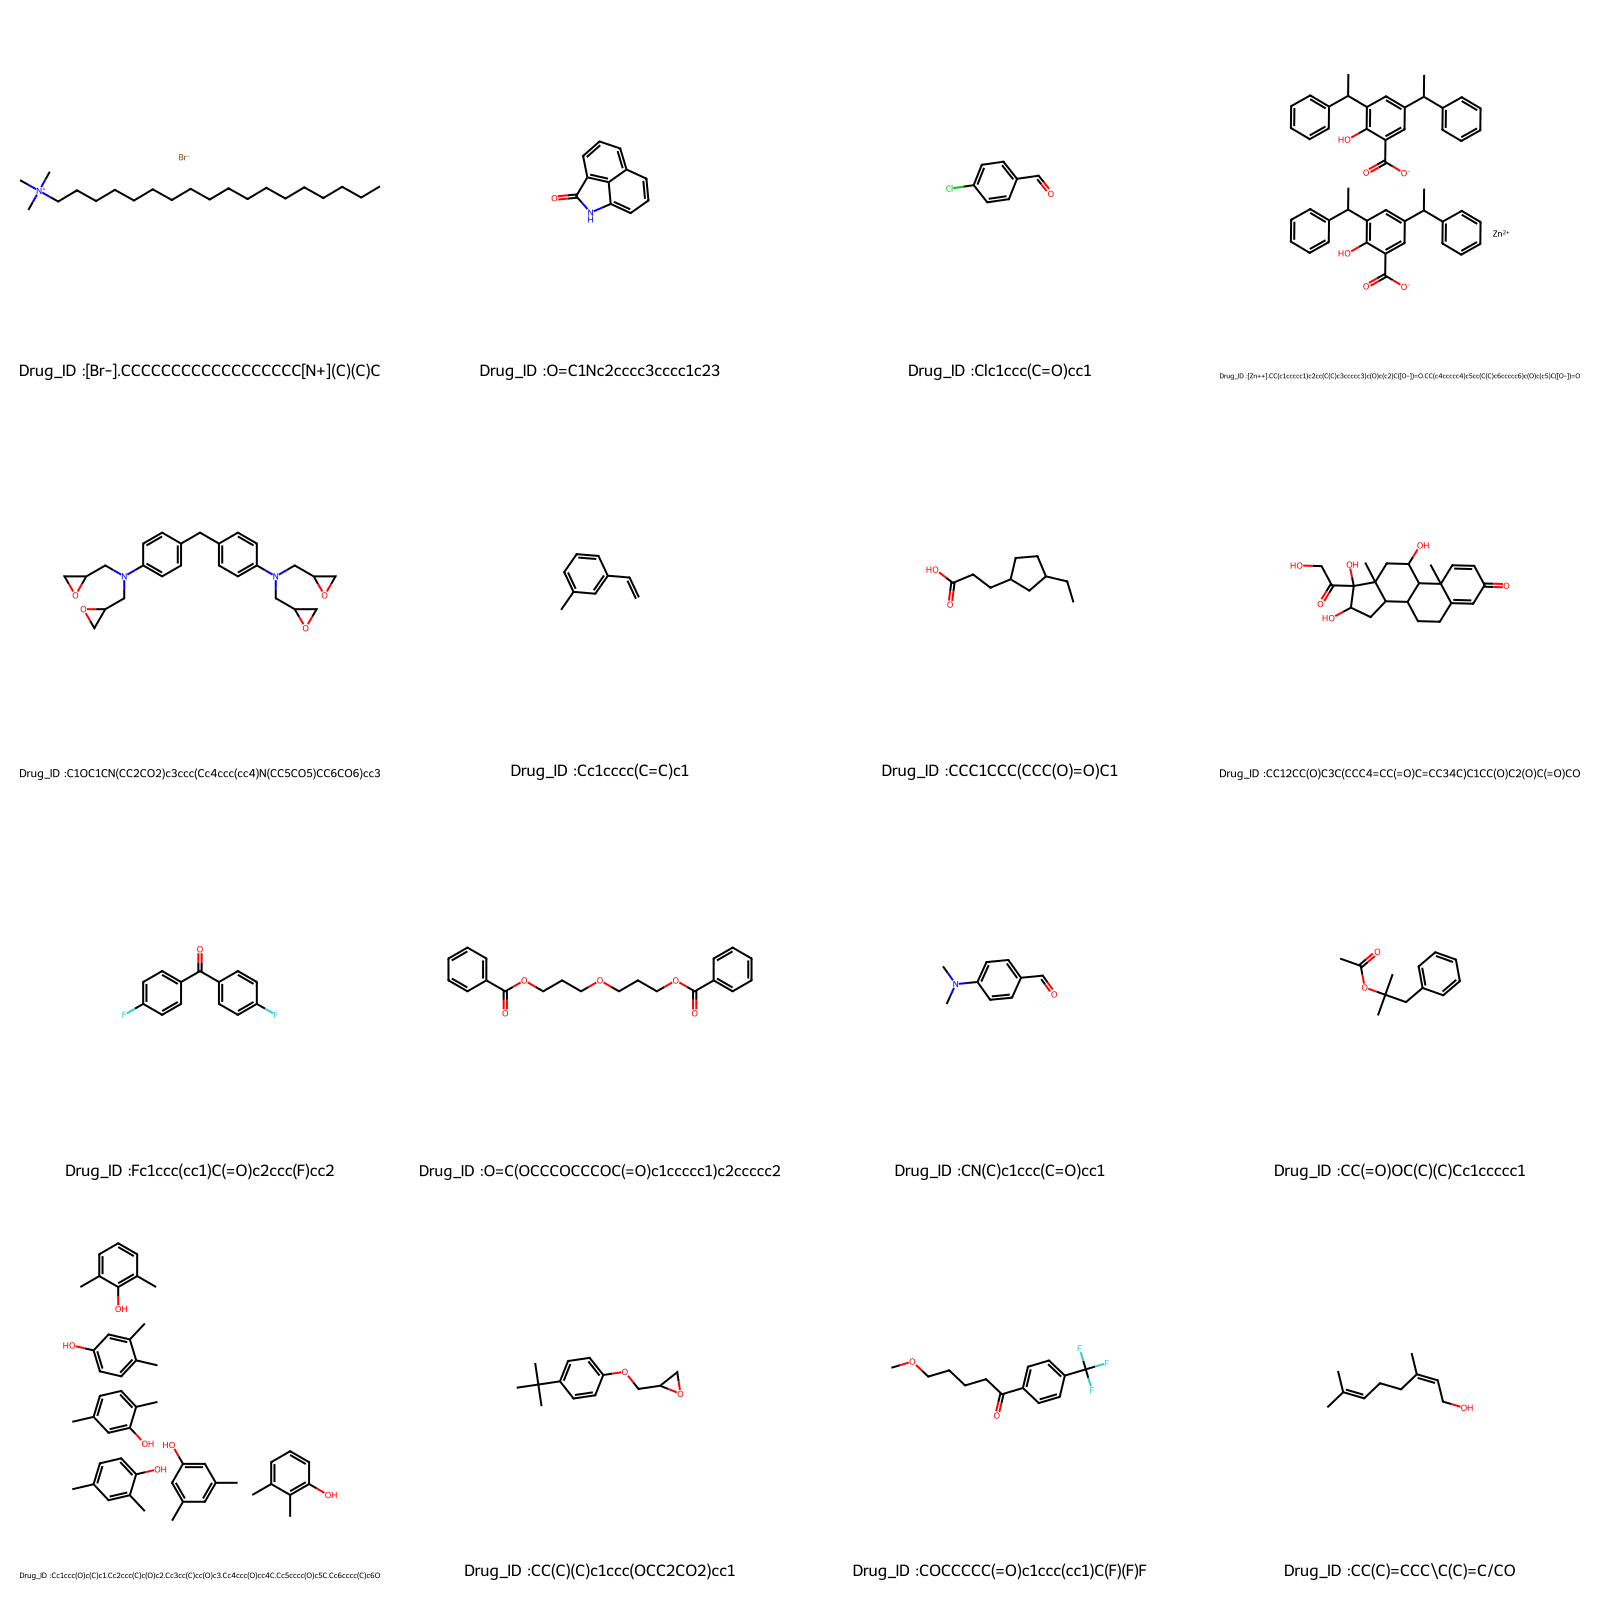

In [70]:
show_smiles(df["Simplified Molecular Input Line Entry System"])

In [71]:
# Convert a SMILES string into a molecular graph representation
smile = df['Simplified Molecular Input Line Entry System'][20]
g = torch_geometric.utils.from_smiles(smile, with_hydrogen=False)
g

Data(x=[14, 9], edge_index=[2, 26], edge_attr=[26, 3], smiles='CC(C)CCCCCOC(=O)CCS')

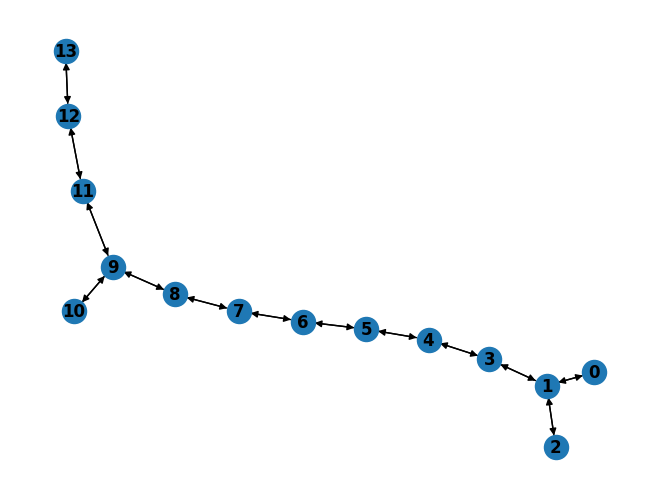

In [73]:
G = torch_geometric.utils.to_networkx(g)
nx.draw(G, with_labels=True, font_weight='bold')
#plt.savefig("G.png")

In [74]:
graph_list = []
for i, smile in enumerate(df["Simplified Molecular Input Line Entry System"]):
    g = torch_geometric.utils.from_smiles(smile) 
    g.x = g.x.float() 
    y = torch.tensor(df['Solubility'][i], dtype=torch.float).view(1, -1) 
    g.y = y
    graph_list.append(g)  

In [ ]:
'''
class MyOwnDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None, pre_filter=None):
        super().__init__(root, transform, pre_transform, pre_filter)
        self.load(self.processed_paths[0])
        
    @property
    def raw_file_names(self):
        return 'curated-solubility-dataset.csv' # Expected raw data file name

    @property
    def processed_file_names(self):
        return 'data.dt' # Processed dataset file name

    def download(self):
        pass

    def process(self):
        # Read data into huge `Data` list.
        graph_list = []
        for i, smile in enumerate(df["SMILES"]):
            g = torch_geometric.util.from_smiles(smile)
            g.x = g.x.float()
            y = torch.tensor(df['Solubility'][i], dtype=torch.float).view(1, -1)
            g.y = y
            graph_list.append(g)   
    

        data_list = graph_list

        if self.pre_filter is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]

        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]

        self.save(data_list, self.processed_paths[0])
'''

In [ ]:
# dataset = MyOwnDataset(root="/kaggle/working/")

In [ ]:
# dataset

----------------------
### **Spliting data**
-------------------

In [75]:
train_ratio = 0.60 
val_ratio = 0.20
test_ratio = 0.20

In [76]:
dataset_size = len(graph_list)
train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)
test_size = dataset_size - train_size - val_size

In [77]:
# First split: Train set and a temporary set (validation + test)
generator1 = torch.Generator().manual_seed(42)
train_dataset, temp_dataset = random_split(graph_list, [train_size, val_size + test_size], generator=generator1)

In [81]:
# Second split: Validation and test sets from the temporary dataset
generator2 = torch.Generator().manual_seed(42)
val_dataset, test_dataset = torch.utils.data.random_split(temp_dataset, [val_size, test_size], generator=generator2)

In [82]:
# Create DataLoaders for training and validation
train_loader = torch_geometric.loader.DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_loader = torch_geometric.loader.DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=True)

In [83]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the AttentiveFP model with specified parameters
model = torch_geometric.nn.AttentiveFP(
    in_channels=9,
    hidden_channels=128,
    out_channels=1,
    edge_dim=3,
    num_layers=5,
    num_timesteps=2,
    dropout=0.3
   ).to(device)

# Define the Adam optimizer with learning rate and weight decay for regularization
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,
                             weight_decay=0.00001)

In [84]:
print(model)

AttentiveFP(in_channels=9, hidden_channels=128, out_channels=1, edge_dim=3, num_layers=5, num_timesteps=2)


In [85]:
def train():
    """
    Trains the model for one epoch and returns the RMSE.
    """
    total_loss = total_samples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        if out.shape[0] != data.y.shape[0]:  # Check if mismatch happens
            print(f"⚠️ Shape mismatch detected in batch {i+1}! Skipping...")
            continue  # Skip broken batch
        loss = F.mse_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
        total_samples += data.num_graphs
    return np.sqrt(total_loss / total_samples)

In [86]:
@torch.no_grad()
def val(loader):
    """
    Evaluates the model on the validation set and returns RMSE.
    """
    mse = []
    model.eval()
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr,data.batch)
        l = F.mse_loss(out, data.y, reduction='none').cpu()
        mse.append(l)
    rmse = float(torch.cat(mse, dim=0).mean().sqrt())
    return rmse

In [87]:
# Training model

# Training parameters
epochs = 200
batch_size = 32  
best_val_rmse = float('inf')
best_model_path = "best_model.pth"

# Progress bar setup
tqdm_bar = tqdm(range(epochs), desc="Training Progress", unit="epoch", 
                bar_format="{l_bar}{bar}{r_bar}", colour="green")

# ---- Training Loop ----
for epoch in tqdm_bar:
    train_rmse = train()  
    val_rmse = val(val_loader)  

    # Save the best model
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), best_model_path)

    tqdm.write(f'Epoch: {epoch:03d}, Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}')
print("Training complete. Best model saved")

Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]/tmp/ipykernel_55/2648773223.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss) * data.num_graphs
Training Progress:   0%|          | 1/200 [00:11<39:05, 11.78s/epoch]

Epoch: 000, Train RMSE: 2.1084, Val RMSE: 1.7413


Training Progress:   1%|          | 2/200 [00:22<35:55, 10.89s/epoch]

Epoch: 001, Train RMSE: 1.6757, Val RMSE: 1.5977


Training Progress:   2%|▏         | 3/200 [00:32<35:06, 10.69s/epoch]

...

Epoch: 197, Train RMSE: 0.3902, Val RMSE: 1.1611


Training Progress: 100%|█████████▉| 199/200 [39:55<00:13, 13.14s/epoch]

Epoch: 198, Train RMSE: 0.3889, Val RMSE: 1.1935


Training Progress: 100%|██████████| 200/200 [40:08<00:00, 12.04s/epoch]

Epoch: 199, Train RMSE: 0.3801, Val RMSE: 1.1638
Training complete. Best model saved


-------------------------------
### **Evalution**
-------------------------------

In [89]:
# Create DataLoaders for test
test_loader = torch_geometric.loader.DataLoader(test_dataset, batch_size=64)
model.load_state_dict(torch.load("best_model.pth", weights_only=True)) # Load the best model

<All keys matched successfully>

In [92]:
@torch.no_grad()
def eval(loader):
    output = []
    smi = []
    model.eval()
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        concatenated_data = torch.cat((out, data.y.view(-1, 1)), dim=1)
        output.append(concatenated_data)
        smi.append(data.smiles)

    # Stack the tensors along batch dimension
    stacked_output = torch.cat(output, dim=0).cpu().numpy()
    stacked_smiles = np.concatenate(smi)
    results = pd.concat([pd.DataFrame(stacked_output, columns=['pred', 'actual']), pd.DataFrame(stacked_smiles, columns=['smiles'])], axis=1)
    
    # Calculate RMSE and R² score
    rmse = mean_squared_error(results['actual'], results['pred'])
    r2 = r2_score(results['actual'], results['pred'])
    
    print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")
    return results, rmse, r2

In [93]:
test_results_df, test_rmse, test_r2 = eval(test_loader)
print(test_results_df.head(30))

RMSE: 1.1370, R²: 0.7892
        pred    actual                                             smiles
0  -2.776121 -2.041100                             CCCCCCCC(C(O)=O)C(O)=O
1  -2.550771 -2.563626                               C=CC(=O)OCCOc1ccccc1
2  -2.249624 -2.150000                          OC(=O)COC1=C(Cl)C=CC=C1Cl
3  -1.162402 -1.628641                                      Nc1ccc(Cl)cc1
4  -7.414367 -7.133804    CCCCCCCCCCCCCCCCOC(=O)Oc1c(Cl)cc(cc1Cl)C(=O)OCC
5  -2.906729 -3.160000                           O=C(C1CCCC1)N(O)C1CCCCC1
6  -3.092114 -2.600000  CC(C)(CF)N1C=C(C(=O)O)C(=O)C2=C1C=C(N1CCNCC1)C...
7  -1.382174 -2.310000                 CC(=O)NC(CC1=CNC2=C1C=CC=C2)C(=O)O
8  -1.296654 -2.173896  [Na+].Nc1c(cc(Nc2ccccc2)c3C(=O)c4ccccc4C(=O)c1...
9  -1.453510 -1.209646  [Na+].[K+].Oc1ccc2ccccc2c1N=Nc3ccc(cc3)N=Nc4cc...
10 -7.048364 -7.138755  OC(COc1ccc(c(O)c1)C(=O)c2ccccc2)COc3ccc(c(O)c3...
11 -5.213319 -5.923157                                    CCCCCCCCCCC1CO1
12 -6.423499 

----------------------------------
# <center><strong>Conclusion</strong></center>
--------------------------------------------
#### **In this study, a graph-based deep learning approach was employed to predict molecular solubility using an Attentive Fingerprint (AttentiveFP) model. By representing molecules as graphs derived directly from SMILES strings, the model was able to effectively capture both atomic-level features and bond-level interactions, preserving the intrinsic chemical structure of each compound.**

#### **The trained model achieved a strong predictive performance on the test set, with an RMSE of 1.137 and an R² score of 0.789, indicating that nearly 79% of the variance in solubility was successfully explained. The close agreement observed between predicted and experimental solubility values across a diverse set of molecules demonstrates the robustness and generalization capability of the GNN-based approach.**

#### **Notably, the model performed consistently across a wide solubility range, including highly soluble and poorly soluble compounds, highlighting its ability to learn complex, non-linear relationships between molecular structure and solubility. Minor deviations between predicted and actual values can be attributed to experimental uncertainty and intrinsic chemical complexity, particularly for highly charged or structurally complex molecules.**

#### **Overall, these results confirm that Graph Neural Networks, when combined with chemically informed molecular representations, provide a powerful and scalable framework for solubility prediction. This approach offers a promising alternative to traditional descriptor-based machine learning models and can be readily extended to other molecular property prediction tasks in cheminformatics and drug discovery.**

---------------------------------------

In [88]:
# !jupyter nbconvert --to html "filename.ipynb"